In [1]:
#1. kiểm tra kết quả assemble_txn.py
import pyarrow.parquet as pq
import pandas as pd, numpy as np, gc
data_dir  = "dataset_high"
tx_path   = f"{data_dir}/transaction_features.parquet"
asof_path = f"{data_dir}/node_edge_features.parquet"
label     = "Is Laundering"
key_cols  = ["src", "dest"]
leak      = ["is_mule", "is_edge_mule"]
def feat_cols(path, drop):
    return [c for c in pq.ParquetFile(path).schema_arrow.names if c not in drop]
def main():
    tx_cols   = feat_cols(tx_path,   set(key_cols + [label, "split"]))
    asof_cols = feat_cols(asof_path, {"split", "ori_idx"})
    dup = sorted(set(tx_cols) & set(asof_cols))
    if dup: raise AssertionError(f"trùng tên cột giữa hai file: {dup}")
    bad = [c for c in leak if c in tx_cols or c in asof_cols]
    if bad: raise AssertionError(f"cột suy từ nhãn lọt vào feature: {bad}")
    meta_tx = pd.read_parquet(tx_path,   columns=[label, "split"])
    meta_asof = pd.read_parquet(asof_path, columns=["split"])
    if len(meta_tx) != len(meta_asof):
        raise AssertionError(f"số dòng lệch: {len(meta_tx):,} vs {len(meta_asof):,}")
    n_bad = int((meta_tx["split"].values != meta_asof["split"].values).sum())
    if n_bad: raise AssertionError(f"{n_bad:,} dòng lệch 'split'")
    del meta_asof; gc.collect()
    y=meta_tx[label].to_numpy(dtype="int8")
    split = meta_tx["split"].to_numpy()
    n=len(y)
    del meta_tx; gc.collect()
    print(f"[align] {n:,} dòng khớp thứ tự")
    names = tx_cols + asof_cols
    X = np.empty((n, len(names)), dtype="float32")
    j = 0
    for path, cols in ((tx_path, tx_cols), (asof_path, asof_cols)):
        pf = pq.ParquetFile(path)
        for c in cols:
            v = pf.read(columns=[c]).column(0).to_numpy(zero_copy_only=False)
            v = v.astype("float32", copy=False)
            if not np.isfinite(v).all():
                raise AssertionError(f"NaN/inf ở cột: {c}")
            X[:, j] = v; j += 1
            del v
        del pf; gc.collect()
    print(f"[build] {len(tx_cols)} tx + {len(asof_cols)} as-of = {j} feature, không NaN/inf")
    return X,y, split, names
X, y, split, names = main()
    

[align] 5,078,345 dòng khớp thứ tự
[build] 32 tx + 63 as-of = 95 feature, không NaN/inf


In [1]:
#2. split dữ liệu và tỷ lệ gian lận giữa các split
import pandas as pd
df = pd.read_csv("dataset_high/HI-Small_Trans_split_index.csv")
for s in ["train", "val", "test"]:
    sub = df[df["split"] == s]
    n = len(sub)
    pos = int(sub["Is Laundering"].sum())
    rate = pos / n * 100
    ratio = (n - pos) / pos
    print(f"{s:5s}  n={n:>10,}  pos={pos:>5,}  {rate:.4f}%   neg/pos = {ratio:>6.1f}")

train  n= 3,046,861  pos=2,297  0.0754%   neg/pos = 1325.5
val    n= 1,015,602  pos=1,082  0.1065%   neg/pos =  937.6
test   n= 1,015,882  pos=1,798  0.1770%   neg/pos =  564.0


In [1]:
#3,4. chạy cái này trước khi kiểm tra và tune mô hình (cell 2)
import json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from metrics import find_best_threshold, evaluate
warnings.filterwarnings("ignore")

DATA_DIR = "dataset_high"
SUB      = 1000000        

def load(split, n_tail=None):
    df = pd.read_parquet(f"{DATA_DIR}/txn_matrix_{split}.parquet")
    if n_tail: df = df.iloc[-n_tail:]
    y = df.pop("Is Laundering").to_numpy()
    return df.to_numpy("float32"), y

X_tr, y_tr = load("train", SUB)
X_va, y_va = load("val")
sc = StandardScaler().fit(X_tr)
X_tr_s, X_va_s = sc.transform(X_tr), sc.transform(X_va)
SPW = (y_tr == 0).sum() / y_tr.sum()

print(f"sweep-train {X_tr.shape} pos={y_tr.sum()} ({y_tr.mean()*100:.4f}%)")
print(f"val         {X_va.shape} pos={y_va.sum()} ({y_va.mean()*100:.4f}%)")
print(f"scale_pos_weight đầy đủ = {SPW:.0f}")

sweep-train (1000000, 95) pos=1219 (0.1219%)
val         (1015602, 95) pos=1082 (0.1065%)
scale_pos_weight đầy đủ = 819


In [11]:
# A. kiểm tra đầu ra val (xgboost)
import pyarrow.parquet as pq
import pandas as pd, numpy as np

cols = pq.ParquetFile(f"{DATA_DIR}/txn_matrix_train.parquet").schema_arrow.names
probe = ["src_cnt", "src_active_time", "src_first_seen",
         "dest_cnt", "dest_active_time", "pair_cnt"]
probe = [c for c in probe if c in cols]

rows = []
for s in ["train", "val", "test"]:
    d = pd.read_parquet(f"{DATA_DIR}/txn_matrix_{s}.parquet",
                        columns=probe + ["Is Laundering"])
    rows.append({"split": s, "n": len(d),
                 "illicit_%": d["Is Laundering"].mean() * 100,
                 **{c: d[c].mean() for c in probe}})
    del d
print(pd.DataFrame(rows).set_index("split").round(3).to_string())

             n  illicit_%  src_cnt  src_active_time  src_first_seen  dest_cnt  dest_active_time  pair_cnt
split                                                                                                    
train  3046861      0.075    0.000            0.000           0.162     0.000             0.000     0.000
val    1015602      0.107    0.666            0.776           0.002     1.299             0.773     1.430
test   1015882      0.177    0.647            0.832           0.002     1.446             0.834     1.446


In [12]:
# B. ngưỡng val có chuyển được sang test không (xgboost kiểm tra đầu ra)
import numpy as np
from metrics import find_best_threshold, evaluate

y_te = pd.read_parquet(f"{DATA_DIR}/txn_matrix_test.parquet",
                       columns=["Is Laundering"])["Is Laundering"].to_numpy()

for seed in range(5):
    s_va = np.load(f"scores/xgb_seed{seed}_val.npy")
    s_te = np.load(f"scores/xgb_seed{seed}_test.npy")
    thr_v = find_best_threshold(y_va, s_va)      # ngưỡng chuyển từ val
    thr_t = find_best_threshold(y_te, s_te)      # ngưỡng tối ưu oracle trên test
    print(f"seed{seed}  thr_val={thr_v:.4f} thr_test={thr_t:.4f} | "
          f"test f1@thr_val={evaluate(y_te, s_te, thr_v)['f1_minority']*100:5.2f}  "
          f"f1@0.5={evaluate(y_te, s_te, 0.5)['f1_minority']*100:5.2f}  "
          f"f1@oracle={evaluate(y_te, s_te, thr_t)['f1_minority']*100:5.2f}")

seed0  thr_val=0.4045 thr_test=0.4160 | test f1@thr_val=70.46  f1@0.5=69.55  f1@oracle=70.52
seed1  thr_val=0.4362 thr_test=0.4050 | test f1@thr_val=68.88  f1@0.5=69.08  f1@oracle=69.48
seed2  thr_val=0.4449 thr_test=0.4823 | test f1@thr_val=69.03  f1@0.5=69.02  f1@oracle=69.18
seed3  thr_val=0.4284 thr_test=0.4251 | test f1@thr_val=70.20  f1@0.5=69.78  f1@oracle=70.36
seed4  thr_val=0.4461 thr_test=0.4288 | test f1@thr_val=69.75  f1@0.5=69.40  f1@oracle=70.21


In [13]:
# C. sampler theo đúng khoảng tham số của IBM (GFP Table 3 / AMLworld Table 10)
import json
import numpy as np

def sample_xgb_cfg(rng):
    return {
        "max_depth":        int(rng.integers(1, 16)),                   # (1,15)
        "learning_rate":    round(float(10 ** rng.uniform(-2.5, -1.0)), 5),
        "reg_lambda":       round(float(10 ** rng.uniform(-2.0,  2.0)), 4),
        "scale_pos_weight": round(float(rng.uniform(1.0, 10.0)), 3),
        "colsample_bytree": round(float(rng.uniform(0.5, 1.0)), 3),
        "subsample":        round(float(rng.uniform(0.5, 1.0)), 3),
        "n_estimators":     1000,
        "early_stopping_rounds": 20,
        "tree_method":      "hist",
        "n_jobs":           -1,
    }

In [14]:
# D. successive halving. eta=2, r0=0.125, x0=256  (~128 lần fit quy đổi toàn tập)
#    Muốn đúng cấu hình IBM cho AML-Small: X0=1000, R0=0.1
import time, json
import numpy as np, pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from metrics import find_best_threshold, evaluate

X0, ETA, R0 = 256, 2, 0.125
ES_FRAC = 0.1                      # giống hệt train_classical.py
OUT = "tune_xgb_halving.csv"

def fit_eval(cfg, Xs, ys, seed=0):
    cut = int(len(ys) * (1 - ES_FRAC))
    m = XGBClassifier(**cfg, random_state=seed, eval_metric="aucpr")
    t0 = time.time()
    m.fit(Xs[:cut], ys[:cut], eval_set=[(Xs[cut:], ys[cut:])], verbose=False)
    dt = time.time() - t0
    s = m.predict_proba(X_va)[:, 1]
    e_opt = evaluate(y_va, s, find_best_threshold(y_va, s))
    e_half = evaluate(y_va, s, 0.5)
    return {"f1_val": e_opt["f1_minority"], "f1_val@0.5": e_half["f1_minority"],
            "pr_auc": e_opt["pr_auc"], "n_tree": int(m.best_iteration) + 1,
            "fit_s": round(dt, 1)}

rng  = np.random.default_rng(0)
cfgs = [sample_xgb_cfg(rng) for _ in range(X0)]
rows, r, rnd = [], R0, 0

while True:
    n_tail = int(len(y_tr) * r)                 # lấy ĐUÔI train -> giữ trật tự thời gian
    Xs, ys = X_tr[-n_tail:], y_tr[-n_tail:]
    scored = []
    for cfg in tqdm(cfgs, desc=f"round {rnd}  r={r:.3f}  n_cfg={len(cfgs)}"):
        res = fit_eval(cfg, Xs, ys)
        scored.append((res["f1_val"], cfg))
        rows.append({"round": rnd, "r": r, **res,
                     **{k: v for k, v in cfg.items() if k not in
                        ("n_estimators", "early_stopping_rounds", "tree_method", "n_jobs")},
                     "params": json.dumps(cfg)})
    pd.DataFrame(rows).to_csv(OUT, index=False)          # ghi sau mỗi vòng, mất điện không mất hết
    print(f"  round {rnd}: f1 tốt nhất = {max(s for s, _ in scored)*100:.2f}")
    if r >= 1.0:
        break
    scored.sort(key=lambda t: -t[0])
    cfgs = [c for _, c in scored[:max(1, len(cfgs) // ETA)]]
    r = min(1.0, r * ETA)
    rnd += 1

round 0  r=0.125  n_cfg=256: 100%|██████████| 256/256 [05:56<00:00,  1.39s/it]


  round 0: f1 tốt nhất = 53.88


round 1  r=0.250  n_cfg=128: 100%|██████████| 128/128 [05:22<00:00,  2.52s/it]


  round 1: f1 tốt nhất = 57.06


round 2  r=0.500  n_cfg=64: 100%|██████████| 64/64 [06:04<00:00,  5.69s/it]


  round 2: f1 tốt nhất = 62.87


round 3  r=1.000  n_cfg=32: 100%|██████████| 32/32 [07:16<00:00, 13.63s/it]

  round 3: f1 tốt nhất = 63.66


In [15]:
# E. lấy top-8 của vòng cuối, SẮP XẾP TỪ ĐƠN GIẢN ĐẾN PHỨC TẠP
import json, pandas as pd

d = pd.read_csv("tune_xgb_halving.csv")
d = d[d["round"] == d["round"].max()].sort_values("f1_val", ascending=False)
print(d[["f1_val", "f1_val@0.5", "pr_auc", "n_tree", "max_depth",
         "learning_rate", "reg_lambda", "scale_pos_weight",
         "colsample_bytree", "subsample", "fit_s"]].head(12).round(4).to_string(index=False))

top = [json.loads(p) for p in d.head(8)["params"]]
top.sort(key=lambda c: (c["max_depth"], -c["learning_rate"]))   # đơn giản trước
print("\n--- dán khối này vào GRIDS[\"xgb\"] trong train_classical.py ---")
print("    \"xgb\": " + json.dumps(top, indent=8) + ",")

 f1_val  f1_val@0.5  pr_auc  n_tree  max_depth  learning_rate  reg_lambda  scale_pos_weight  colsample_bytree  subsample  fit_s
 0.6366      0.6283  0.6058     301         13         0.0435      0.0200             4.415             0.663      0.785   23.5
 0.6323      0.6259  0.6017     248         15         0.0477      0.4556             7.610             0.856      0.966   18.9
 0.6307      0.6245  0.6065     450         15         0.0369      1.8884             8.434             0.766      0.907   41.9
 0.6297      0.6275  0.6009     158         14         0.0801      0.0176             5.907             0.611      0.851   15.4
 0.6293      0.5946  0.5933     159          6         0.0390      0.1104             5.429             0.891      0.849   10.4
 0.6291      0.6283  0.5952     131          9         0.0812      3.2834             3.026             0.779      0.886   10.2
 0.6272      0.6185  0.6004     251          6         0.0414     25.5566             2.250             

In [17]:
# F. xác nhận top-8 bằng 3 seed trên FULL train -> tune_xgb_confirm.csv
import json, time
import numpy as np, pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from metrics import find_best_threshold, evaluate

CONFIRM_OUT = "tune_xgb_confirm.csv"
CONFIRM_SEEDS = [0, 1, 2]          # = TUNE_SEEDS trong train_classical.py
ES_FRAC = 0.1

# full train (không đụng X_tr của cell 2 để các cell khác vẫn chạy được)
X_full, y_full = load("train")
print(f"full train {X_full.shape} pos={y_full.sum()} ({y_full.mean()*100:.4f}%)")

cut = int(len(y_full) * (1 - ES_FRAC))
Xf, yf, Xe, ye = X_full[:cut], y_full[:cut], X_full[cut:], y_full[cut:]

rows = []
for i, cfg in enumerate(tqdm(top, desc="confirm top-8")):   # `top` từ cell E, đã sort đơn giản -> phức tạp
    for seed in CONFIRM_SEEDS:
        m = XGBClassifier(**cfg, random_state=seed, eval_metric="aucpr")
        t0 = time.time()
        m.fit(Xf, yf, eval_set=[(Xe, ye)], verbose=False)
        dt = time.time() - t0
        s = m.predict_proba(X_va)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        e_half = evaluate(y_va, s, 0.5)   
        rows.append({"cfg_id": i, "seed": seed,
                     "f1_val": e["f1_minority"], "f1_val@0.5": e_half["f1_minority"],
                     "pr_auc": e["pr_auc"], "n_tree": int(m.best_iteration) + 1,
                     "fit_s": round(dt, 1),
                     **{k: v for k, v in cfg.items() if k not in
                        ("n_estimators", "early_stopping_rounds", "tree_method", "n_jobs")},
                     "params": json.dumps(cfg)})
    pd.DataFrame(rows).to_csv(CONFIRM_OUT, index=False)      # ghi sau mỗi cfg

# --- tổng hợp: f1_mean ± SE, rồi quy tắc 1-SE giống pick_best() ---
d = pd.DataFrame(rows)
g = d.groupby("cfg_id")
agg = pd.DataFrame({
    "f1_mean": g.f1_val.mean() * 100,
    "f1_sd":   g.f1_val.std(ddof=1) * 100,
    "n_tree":  g.n_tree.mean().round(0),
    "fit_s":   g.fit_s.mean().round(1),
    "max_depth":        g.max_depth.first(),
    "learning_rate":    g.learning_rate.first(),
    "reg_lambda":       g.reg_lambda.first(),
    "scale_pos_weight": g.scale_pos_weight.first(),
}).reset_index()
agg["se"] = agg.f1_sd / np.sqrt(len(CONFIRM_SEEDS))
print(agg.round(4).to_string(index=False))

b = int(agg.f1_mean.idxmax())
cutoff = agg.f1_mean[b] - agg.se[b]
pick = int(next(i for i, mu in enumerate(agg.f1_mean) if mu >= cutoff))
print(f"\nbest theo mean = cfg_id {b} (f1={agg.f1_mean[b]:.2f}, SE={agg.se[b]:.2f}) "
      f"-> cutoff {cutoff:.2f}")
print(f"chọn theo 1-SE (đơn giản nhất đạt cutoff) = cfg_id {pick} "
      f"(f1={agg.f1_mean[pick]:.2f})")
print("\n--- gán vào train_classical.py: PARAMS[\"xgb\"] = ---")
print(json.dumps(top[pick], indent=4))

full train (3046861, 95) pos=2297 (0.0754%)


confirm top-8: 100%|██████████| 8/8 [16:56<00:00, 127.02s/it]

 cfg_id  f1_mean  f1_sd  n_tree  fit_s  max_depth  learning_rate  reg_lambda  scale_pos_weight     se
      0  61.8998 0.5890   331.0   56.6          6         0.0414     25.5566             2.250 0.3401
      1  61.7617 0.4874   247.0   46.2          6         0.0390      0.1104             5.429 0.2814
      2  63.2931 0.4235    99.0   23.8          9         0.0812      3.2834             3.026 0.2445
      3  63.5514 0.1389   165.0   40.6         13         0.0435      0.0200             4.415 0.0802
      4  63.4635 0.5441   118.0   33.5         14         0.0801      0.0176             5.907 0.3141
      5  63.3236 1.0466   119.0   34.3         15         0.0891      0.2335             8.418 0.6043
      6  63.0498 0.2809   188.0   46.4         15         0.0477      0.4556             7.610 0.1622
      7  62.3375 0.0485   190.0   44.8         15         0.0369      1.8884             8.434 0.0280

best theo mean = cfg_id 3 (f1=63.55, SE=0.08) -> cutoff 63.47
chọn theo 1-SE (đơn

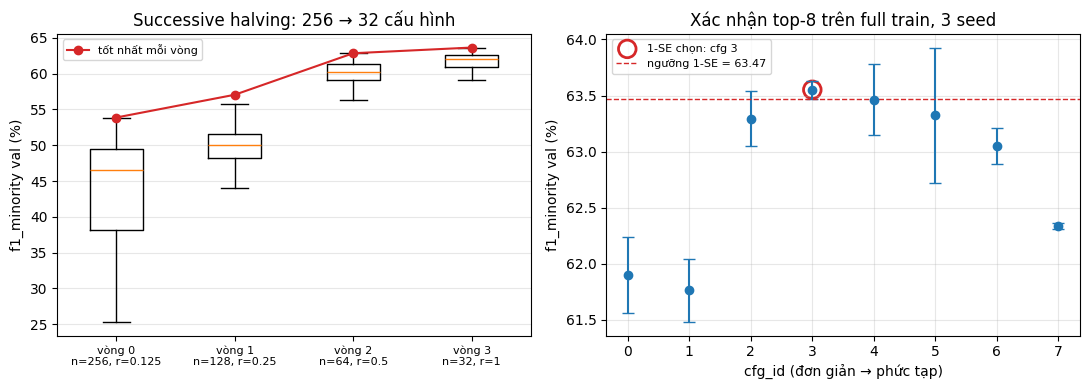

In [7]:
# H2. xgb: biểu đồ quy trình chọn tham số (successive halving + xác nhận top-8)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

hal = pd.read_csv("tune_xgb_halving.csv")
con = pd.read_csv("tune_xgb_confirm.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# --- trái: phân bố f1 qua từng vòng halving
rounds = sorted(hal["round"].unique())
data = [hal.loc[hal["round"] == r, "f1_val"].values * 100 for r in rounds]
ax1.boxplot(data, showfliers=False)
ax1.set_xticks(range(1, len(rounds) + 1))
ax1.set_xticklabels([f"vòng {r}\nn={len(data[i])}, r={hal.loc[hal['round']==r,'r'].iloc[0]:g}"
                     for i, r in enumerate(rounds)], fontsize=8)
ax1.plot(range(1, len(rounds) + 1), [d.max() for d in data],
         marker="o", color="tab:red", label="tốt nhất mỗi vòng")
ax1.set_ylabel("f1_minority val (%)")
ax1.set_title("Successive halving: 256 → 32 cấu hình")
ax1.legend(fontsize=8); ax1.grid(alpha=.3, axis="y")

# --- phải: xác nhận top-8 bằng 3 seed, kèm ngưỡng 1-SE
g = con.groupby("cfg_id").f1_val
mu, se = g.mean() * 100, g.std(ddof=1) / np.sqrt(g.count()) * 100
b = mu.idxmax(); cutoff = mu[b] - se[b]
chosen = next(i for i in sorted(mu.index) if mu[i] >= cutoff)

ax2.errorbar(mu.index, mu.values, yerr=se.values, fmt="o", capsize=4, color="tab:blue")
ax2.scatter([chosen], [mu[chosen]], s=160, facecolors="none",
            edgecolors="tab:red", linewidths=2, label=f"1-SE chọn: cfg {chosen}")
ax2.axhline(cutoff, ls="--", color="tab:red", lw=1, label=f"ngưỡng 1-SE = {cutoff:.2f}")
ax2.set_xlabel("cfg_id (đơn giản → phức tạp)")
ax2.set_ylabel("f1_minority val (%)")
ax2.set_title("Xác nhận top-8 trên full train, 3 seed")
ax2.legend(fontsize=8); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

In [4]:
# H. áp quy tắc 1-SE lên tune_xgb_confirm.csv -> chứng minh tiêu chí thống nhất
#    (không cần train lại: đọc thẳng từ CSV đã có)
import json
import numpy as np
import pandas as pd

d = pd.read_csv("tune_xgb_confirm.csv")
g = d.groupby("cfg_id").f1_val
mu = g.mean()
se = g.std(ddof=1) / np.sqrt(g.count())

b = mu.idxmax()
cutoff = mu[b] - se[b]
# cfg_id đã được cell E sắp xếp từ ĐƠN GIẢN đến PHỨC TẠP
# -> lấy cfg đầu tiên đạt cutoff = đúng logic pick_best() trong train_classical.py
chosen = next(i for i in sorted(mu.index) if mu[i] >= cutoff)

print("--- xgb: quy tắc 1-SE trên tune_xgb_confirm.csv ---")
print(f"  argmax      : cfg {b}  mean={mu[b]:.6f}  se={se[b]:.6f}")
print(f"  ngưỡng 1-SE : {cutoff:.6f}\n")
print("  cfg  max_depth   mean       se        đạt ngưỡng")
for i in sorted(mu.index):
    md = int(d.loc[d.cfg_id == i, "max_depth"].iloc[0])
    print(f"   {i}      {md:>2}      {mu[i]:.6f}  {se[i]:.6f}   "
          f"{'X' if mu[i] >= cutoff else '.'}")

p_1se = json.loads(d.loc[d.cfg_id == chosen, "params"].iloc[0])
print(f"\n  1-SE chọn   : cfg {chosen}")
print(f"  argmax chọn : cfg {b}")
print(f"  hai tiêu chí trùng nhau? {chosen == b}")
print(f"\n  params 1-SE : {json.dumps(p_1se)}")

# đối chiếu với tham số đang hardcode trong train_classical.py
from train_classical import GRIDS
p_code = GRIDS["xgb"][0]
same = all(abs(p_1se[k] - p_code[k]) < 1e-9 for k in
           ["max_depth", "learning_rate", "reg_lambda",
            "scale_pos_weight", "colsample_bytree", "subsample"])
print(f"  khớp với GRIDS['xgb'] trong train_classical.py? {same}")

--- xgb: quy tắc 1-SE trên tune_xgb_confirm.csv ---
  argmax      : cfg 3  mean=0.635514  se=0.000802
  ngưỡng 1-SE : 0.634712

  cfg  max_depth   mean       se        đạt ngưỡng
   0       6      0.618998  0.003401   .
   1       6      0.617617  0.002814   .
   2       9      0.632931  0.002445   .
   3      13      0.635514  0.000802   X
   4      14      0.634635  0.003141   .
   5      15      0.633236  0.006043   .
   6      15      0.630498  0.001622   .
   7      15      0.623375  0.000280   .

  1-SE chọn   : cfg 3
  argmax chọn : cfg 3
  hai tiêu chí trùng nhau? True

  params 1-SE : {"max_depth": 13, "learning_rate": 0.0435, "reg_lambda": 0.02, "scale_pos_weight": 4.415, "colsample_bytree": 0.663, "subsample": 0.785, "n_estimators": 1000, "early_stopping_rounds": 20, "tree_method": "hist", "n_jobs": -1}
  khớp với GRIDS['xgb'] trong train_classical.py? True


In [20]:
# 3. lr: seed có đổi nghiệm không (chạy sau cell 2)
#    Kiem tra o dung cau hinh cuoi cung dung de bao cao.
C_BEST, TOL, MAX_ITER = 10.0, 1e-8, 20000
m0 = LogisticRegression(C=C_BEST, tol=TOL, max_iter=MAX_ITER, random_state=0).fit(X_tr_s, y_tr)
m1 = LogisticRegression(C=C_BEST, tol=TOL, max_iter=MAX_ITER, random_state=42).fit(X_tr_s, y_tr)
# print("--- lr: seed co doi nghiem khong ---")
# print(f"  coef trung khit    = {np.array_equal(m0.coef_, m1.coef_)}")
# print(f"  sai khac tuyet doi = {np.abs(m0.coef_ - m1.coef_).max():.3e}")
# print("  -> True/0.0 nghia la SEEDS va TUNE_SEEDS cho lr chi lap lai 1 ket qua")

--- lr: seed có đổi nghiệm không ---
  coef trùng khít     = True
  sai khác tuyệt đối  = 0.000e+00
  -> nếu True/0.0 thì TUNE_SEEDS và SEEDS cho lr chỉ lặp lại 1 kết quả

--- lr: class_weight x C (f1 trên val, ngưỡng tối ưu val) ---
  cw=None      C=0.01   n_iter=21    f1=48.24  pr_auc=44.34  thr=0.23214  b0=-10.733  |w|=  13.21  (2s)
  cw=None      C=0.1    n_iter=27    f1=48.29  pr_auc=45.32  thr=0.23127  b0=-12.100  |w|=  16.84  (2s)
  cw=None      C=1.0    n_iter=27    f1=48.28  pr_auc=45.44  thr=0.28572  b0=-12.378  |w|=  17.54  (2s)
  cw=None      C=10.0   n_iter=27    f1=48.25  pr_auc=45.45  thr=0.23821  b0=-12.409  |w|=  17.61  (2s)
  cw=None      C=100.0  n_iter=27    f1=48.28  pr_auc=45.45  thr=0.23840  b0=-12.412  |w|=  17.62  (2s)
  cw=balanced  C=0.01   n_iter=169   f1=38.31  pr_auc=34.68  thr=0.99550  b0= -6.724  |w|=  35.28  (11s)
  cw=balanced  C=0.1    n_iter=299   f1=37.55  pr_auc=34.44  thr=0.99631  b0= -7.983  |w|=  71.66  (17s)
  cw=balanced  C=1.0    n_iter=513  

  cw=None      C=0.0001    n_iter=17    hoi_tu=True  f1=30.93  pr_auc=24.64  |w|=    2.65  (1s)
  cw=None      C=0.001     n_iter=18    hoi_tu=True  f1=43.10  pr_auc=37.70  |w|=    6.99  (1s)
  cw=None      C=0.01      n_iter=21    hoi_tu=True  f1=48.24  pr_auc=44.34  |w|=   13.21  (1s)
  cw=None      C=0.1       n_iter=27    hoi_tu=True  f1=48.29  pr_auc=45.32  |w|=   16.84  (2s)
  cw=None      C=1         n_iter=27    hoi_tu=True  f1=48.28  pr_auc=45.44  |w|=   17.54  (2s)
  cw=None      C=10        n_iter=27    hoi_tu=True  f1=48.25  pr_auc=45.45  |w|=   17.61  (2s)
  cw=None      C=100       n_iter=27    hoi_tu=True  f1=48.28  pr_auc=45.45  |w|=   17.62  (2s)
  cw=None      C=1000      n_iter=27    hoi_tu=True  f1=48.28  pr_auc=45.45  |w|=   17.62  (2s)
  cw=balanced  C=0.0001    n_iter=37    hoi_tu=True  f1=36.75  pr_auc=32.08  |w|=   11.10  (3s)
  cw=balanced  C=0.001     n_iter=71    hoi_tu=True  f1=38.50  pr_auc=34.06  |w|=   20.69  (5s)
  cw=balanced  C=0.01      n_iter=169   

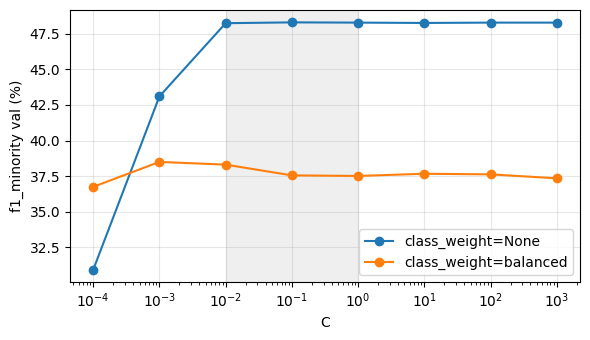


  coarse best: cw=None C=0.1 f1=48.29
  chạm biên trái?  False   chạm biên phải? False
  có cấu hình nào chưa hội tụ? False


In [21]:
# G1. lr: quét thô C theo log-scale x class_weight  (chạy sau cell 2)
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt

C_COARSE = np.logspace(-4, 3, 8)      # 1e-4 ... 1e3
MAX_ITER = 20000                       # nới rộng: C lớn hội tụ chậm hơn

rows = []
for cw in [None, "balanced"]:
    for C in C_COARSE:
        m = LogisticRegression(C=C, class_weight=cw, max_iter=MAX_ITER, random_state=0)
        t0 = time.time(); m.fit(X_tr_s, y_tr); el = time.time() - t0
        s = m.predict_proba(X_va_s)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        n_it = int(m.n_iter_[0])
        rows.append({"cw": str(cw), "C": float(C), "n_iter": n_it,
                     "hoi_tu": n_it < MAX_ITER,
                     "f1": e["f1_minority"] * 100, "pr_auc": e["pr_auc"] * 100,
                     "w_norm": float(np.abs(m.coef_).sum()), "s": round(el)})
        r = rows[-1]
        print(f"  cw={r['cw']:<9} C={C:<9.4g} n_iter={n_it:<5} hoi_tu={str(r['hoi_tu']):<5} "
              f"f1={r['f1']:5.2f}  pr_auc={r['pr_auc']:5.2f}  |w|={r['w_norm']:8.2f}  ({r['s']}s)")

lr_coarse = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 3.5))
for cw, g in lr_coarse.groupby("cw"):
    ax.plot(g.C, g.f1, marker="o", label=f"class_weight={cw}")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("f1_minority val (%)")
ax.axvspan(0.01, 1.0, alpha=0.12, color="gray")   # grid hiện tại trong train_classical.py
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

best = lr_coarse.loc[lr_coarse.f1.idxmax()]
print(f"\n  coarse best: cw={best.cw} C={best.C:.4g} f1={best.f1:.2f}")
print(f"  chạm biên trái?  {best.C == C_COARSE[0]}   chạm biên phải? {best.C == C_COARSE[-1]}")
print(f"  có cấu hình nào chưa hội tụ? {(~lr_coarse.hoi_tu).any()}")
#tham số chọn là 

  cw=None      C=0.0001    n_iter=28     cham_tran=False f1=31.06  pr_auc=24.70  |w|=    2.64  (3s)
  cw=None      C=0.001     n_iter=55     cham_tran=False f1=42.33  pr_auc=37.32  |w|=    6.98  (3s)
  cw=None      C=0.01      n_iter=127    cham_tran=False f1=48.89  pr_auc=45.22  |w|=   13.96  (8s)
  cw=None      C=0.1       n_iter=295    cham_tran=False f1=51.07  pr_auc=47.93  |w|=   22.77  (21s)
  cw=None      C=1         n_iter=760    cham_tran=False f1=51.70  pr_auc=48.57  |w|=   34.79  (45s)
  cw=None      C=10        n_iter=1832   cham_tran=False f1=51.95  pr_auc=48.88  |w|=   60.27  (160s)
  cw=None      C=100       n_iter=3218   cham_tran=False f1=51.77  pr_auc=48.99  |w|=   93.12  (237s)
  cw=None      C=1000      n_iter=3069   cham_tran=False f1=51.77  pr_auc=49.01  |w|=  106.67  (276s)
  cw=balanced  C=0.0001    n_iter=86     cham_tran=False f1=36.75  pr_auc=32.10  |w|=   11.10  (10s)
  cw=balanced  C=0.001     n_iter=222    cham_tran=False f1=38.45  pr_auc=34.09  |w|=   20.

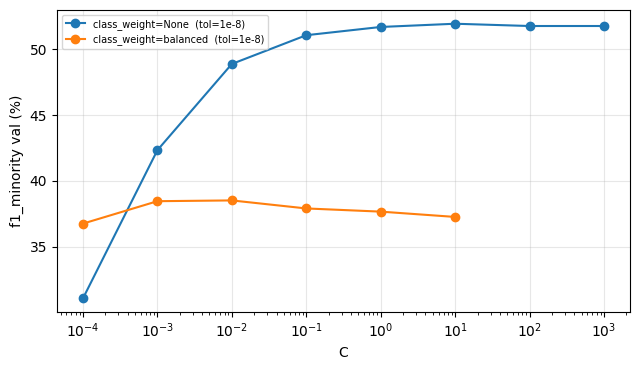

  None      best C=10 f1=51.95  cham biên trái? False  chạm biên phải? False
  balanced  best C=0.01 f1=38.51  cham biên trái? False  chạm biên phải? False


In [8]:
# G6. lr: quét lại G1 ở tol=1e-8 (chạy sau cell 2)
#     G1 chạy ở tol mặc định 1e-4 -> G5 cho thấy solver dừng quá sớm.
#     
C_FULL = np.logspace(-4, 3, 8)
C_BAL  = np.logspace(-4, 1, 6)
MAX_ITER = 20000
TOL      = 1e-8

rows = []
for cw, Cs in [(None, C_FULL), ("balanced", C_BAL)]:
    for C in Cs:
        m = LogisticRegression(C=C, class_weight=cw, max_iter=MAX_ITER,
                               tol=TOL, random_state=0)
        t0 = time.time(); m.fit(X_tr_s, y_tr); el = time.time() - t0
        s = m.predict_proba(X_va_s)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        n_it = int(m.n_iter_[0])
        rows.append({"cw": str(cw), "C": float(C), "n_iter": n_it,
                     "cham_tran": n_it >= MAX_ITER,
                     "f1": e["f1_minority"] * 100, "pr_auc": e["pr_auc"] * 100,
                     "w_norm": float(np.abs(m.coef_).sum()), "s": round(el)})
        r = rows[-1]
        print(f"  cw={r['cw']:<9} C={C:<9.4g} n_iter={n_it:<6} "
              f"cham_tran={str(r['cham_tran']):<5} f1={r['f1']:5.2f}  "
              f"pr_auc={r['pr_auc']:5.2f}  |w|={r['w_norm']:8.2f}  ({r['s']}s)")

lr_tight = pd.DataFrame(rows)
lr_tight.to_csv("tune_lr.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for cw, g in lr_tight.groupby("cw"):
    ax.plot(g.C, g.f1, marker="o", label=f"class_weight={cw}  (tol=1e-8)")
if "lr_coarse" in globals():          # chong len ket qua G1 neu con trong bo nho
    for cw, g in lr_coarse.groupby("cw"):
        ax.plot(g.C, g.f1, marker=".", ls="--", alpha=.5,
                label=f"class_weight={cw}  (tol=1e-4, G1)")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("f1_minority val (%)")
ax.legend(fontsize=7); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

for cw, Cs in [("None", C_FULL), ("balanced", C_BAL)]:
    g = lr_tight[lr_tight.cw == cw]
    bb = g.loc[g.f1.idxmax()]
    print(f"  {cw:<9} best C={bb.C:.4g} f1={bb.f1:.2f}  "
          f"cham biên trái? {bb.C == Cs[0]}  chạm biên phải? {bb.C == Cs[-1]}")

In [5]:
# I1. rf: quét 9 cấu hình × 3 seed trên sweep-train -> tune_rf.csv
#     n_estimators=100 để so sánh cho nhanh; final trong train_classical.py dùng 300.
#     Cơ sở: results_v0.csv cho thấy thứ hạng cấu hình không đổi giữa 100 và 300 cây.
RF_SEEDS = [0, 1, 2]
RF_GRID = [{"n_estimators": 100, "min_samples_leaf": l, "max_features": mf,
            "class_weight": "balanced", "n_jobs": -1}
           for l in [20, 5, 1] for mf in ["sqrt", 0.3, 0.6]]   # ĐƠN GIẢN -> PHỨC TẠP

rows = []
for cfg_id, cfg in enumerate(RF_GRID):
    for seed in RF_SEEDS:
        m = RandomForestClassifier(**cfg, random_state=seed)
        t0 = time.time(); m.fit(X_tr, y_tr); el = time.time() - t0
        s = m.predict_proba(X_va)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        rows.append({"cfg_id": cfg_id, "seed": seed,
                     "min_samples_leaf": cfg["min_samples_leaf"],
                     "max_features": str(cfg["max_features"]),
                     "f1_val": e["f1_minority"], "pr_auc": e["pr_auc"],
                     "fit_s": round(el, 1), "params": json.dumps(cfg)})
        r = rows[-1]
        print(f"  cfg {cfg_id} msl={r['min_samples_leaf']:<3} mf={r['max_features']:<5} "
              f"seed={seed}  f1={r['f1_val']*100:5.2f}  pr_auc={r['pr_auc']*100:5.2f}  ({r['fit_s']}s)")

tune_rf = pd.DataFrame(rows)
tune_rf.to_csv("tune_rf.csv", index=False)
print(f"\n  đã ghi tune_rf.csv ({len(tune_rf)} dòng, tổng {tune_rf.fit_s.sum()/60:.1f} phut)")

  cfg 0 msl=20  mf=sqrt  seed=0  f1=57.64  pr_auc=53.55  (28.7s)
  cfg 0 msl=20  mf=sqrt  seed=1  f1=57.98  pr_auc=53.22  (28.2s)
  cfg 0 msl=20  mf=sqrt  seed=2  f1=56.40  pr_auc=53.00  (26.8s)
  cfg 1 msl=20  mf=0.3   seed=0  f1=57.37  pr_auc=53.04  (72.9s)
  cfg 1 msl=20  mf=0.3   seed=1  f1=57.41  pr_auc=52.46  (74.0s)
  cfg 1 msl=20  mf=0.3   seed=2  f1=57.64  pr_auc=52.20  (69.8s)
  cfg 2 msl=20  mf=0.6   seed=0  f1=57.53  pr_auc=51.45  (128.0s)
  cfg 2 msl=20  mf=0.6   seed=1  f1=57.55  pr_auc=52.23  (128.3s)
  cfg 2 msl=20  mf=0.6   seed=2  f1=57.48  pr_auc=50.92  (131.9s)
  cfg 3 msl=5   mf=sqrt  seed=0  f1=58.59  pr_auc=53.75  (28.0s)
  cfg 3 msl=5   mf=sqrt  seed=1  f1=58.80  pr_auc=52.50  (28.3s)
  cfg 3 msl=5   mf=sqrt  seed=2  f1=58.65  pr_auc=51.87  (32.0s)
  cfg 4 msl=5   mf=0.3   seed=0  f1=58.86  pr_auc=47.95  (65.2s)
  cfg 4 msl=5   mf=0.3   seed=1  f1=59.56  pr_auc=48.56  (76.1s)
  cfg 4 msl=5   mf=0.3   seed=2  f1=59.38  pr_auc=47.99  (63.4s)
  cfg 5 msl=5   mf=0.6

--- rf: quy tac 1-SE tren tune_rf.csv ---
  argmax      : cfg 4  mean=0.592653  se=0.002072
  nguong 1-SE : 0.590581

  cfg  msl  max_features    mean       se        dat nguong
   0    20   sqrt        0.573412  0.004785   .
   1    20   0.3         0.574739  0.000847   .
   2    20   0.6         0.575178  0.000196   .
   3     5   sqrt        0.586795  0.000643   .
   4     5   0.3         0.592653  0.002072   X
   5     5   0.6         0.588680  0.000346   .
   6     1   sqrt        0.567586  0.006665   .
   7     1   0.3         0.557647  0.009959   .
   8     1   0.6         0.494903  0.010556   .

  1-SE chon: cfg 4   (argmax: cfg 4)


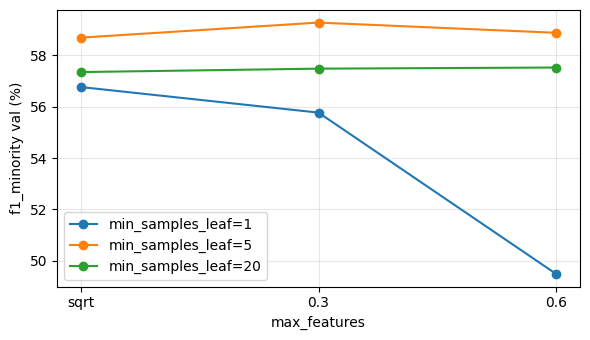


  dan vao GRIDS['rf'] trong train_classical.py:
{
    "n_estimators": 300,
    "min_samples_leaf": 5,
    "max_features": 0.3,
    "class_weight": "balanced",
    "n_jobs": -1
}


In [6]:
# I2. rf: áp quy tắc 1-SE lên tune_rf.csv (cùng tiêu chí với lr và xgb)
d = pd.read_csv("tune_rf.csv")
g = d.groupby("cfg_id").f1_val
mu = g.mean(); se = g.std(ddof=1) / np.sqrt(g.count())

b = mu.idxmax()
cutoff = mu[b] - se[b]
chosen = next(i for i in sorted(mu.index) if mu[i] >= cutoff)   # cfg_id xếp đơn giản -> phức tạp

print("--- rf: quy tac 1-SE tren tune_rf.csv ---")
print(f"  argmax      : cfg {b}  mean={mu[b]:.6f}  se={se[b]:.6f}")
print(f"  nguong 1-SE : {cutoff:.6f}\n")
print("  cfg  msl  max_features    mean       se        dat nguong")
for i in sorted(mu.index):
    r = d[d.cfg_id == i].iloc[0]
    print(f"   {i}   {r.min_samples_leaf:>3}   {str(r.max_features):<6}      "
          f"{mu[i]:.6f}  {se[i]:.6f}   {'X' if mu[i] >= cutoff else '.'}")
print(f"\n  1-SE chon: cfg {chosen}   (argmax: cfg {b})")

piv = (d.pivot_table(index="max_features", columns="min_samples_leaf",
                     values="f1_val", aggfunc="mean")
         .reindex(["sqrt", "0.3", "0.6"]) * 100)
fig, ax = plt.subplots(figsize=(6, 3.5))
for msl in piv.columns:
    ax.plot(piv.index, piv[msl], marker="o", label=f"min_samples_leaf={msl}")
ax.set_xlabel("max_features"); ax.set_ylabel("f1_minority val (%)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

p = json.loads(d[d.cfg_id == chosen].params.iloc[0])
p["n_estimators"] = 300          # nang len de train final va bao cao
print("\n  dan vao GRIDS['rf'] trong train_classical.py:")
print(json.dumps(p, indent=4))

In [2]:
# C-lgb. sampler LightGBM theo GFP Table 3 (cot LightGBM), doi xung voi cell C cua xgb
#   num_round        (10,1000)        -> n_estimators=1000 + early_stopping 20 (nhu cell C)
#   num_leaves       (1,16384)        -> LECH GFP: log-uniform 2^k, k=1..14.
#                                        Ly do: xgb lay max_depth uniform (1,15), tuong duong
#                                        LOG-uniform theo so la. Lay uniform 1..16384 se don
#                                        ~99% mau vao cay rat lon -> hai khong gian khong khop.
#   learning_rate    10^(-2.5,-1)     -> giong het xgb
#   lambda_l2        10^(-2,2)        -> reg_lambda, giong het xgb
#   lambda_l1        10^(0.01,0.5)    -> reg_alpha, rieng cua LightGBM trong Table 3
#   scale_pos_weight (1,10)           -> giong het xgb (SUA loi cell J1 dung 835)
#   max_bin                           -> LECH GFP/xgb: 63 thay vi 255/256 (giam chi phi)
import json
import numpy as np

LGB_MAX_BIN = 63          # doi thanh 255 neu muon khop hoan toan voi xgb (hist -> 256)

def sample_lgb_cfg(rng):
    return {
        "num_leaves":       int(2 ** rng.integers(1, 15)),                    # 2 .. 16384
        "learning_rate":    round(float(10 ** rng.uniform(-2.5, -1.0)), 5),
        "reg_lambda":       round(float(10 ** rng.uniform(-2.0,  2.0)), 4),   # lambda_l2
        "reg_alpha":        round(float(10 ** rng.uniform( 0.01, 0.5)), 4),   # lambda_l1
        "scale_pos_weight": round(float(rng.uniform(1.0, 10.0)), 3),
        "n_estimators":     1000,
        "max_bin":          LGB_MAX_BIN,
        "n_jobs":           -1,
        "verbose":          -1,
    }

In [3]:
# D-lgb. successive halving cho LightGBM. eta=2, r0=0.125, x0=256
#        GIONG Y HET cell D cua xgb: cung X_tr / X_va (cell 2), cung ES_FRAC,
#        cung so vong, cung cach lay DUOI train -> so sanh chi phi + F1 cong bang.
import time, json
import numpy as np, pandas as pd
from tqdm import tqdm
import lightgbm as lgb
from metrics import find_best_threshold, evaluate

X0, ETA, R0 = 256, 2, 0.125
ES_FRAC     = 0.1
ES_ROUNDS   = 20                      # GFP: early_stopping_rounds = 20
OUT_LGB     = "tune_lgb_halving.csv"

def fit_eval_lgb(cfg, Xs, ys, seed=0):
    cut = int(len(ys) * (1 - ES_FRAC))
    m = lgb.LGBMClassifier(**cfg, random_state=seed)
    t0 = time.time()
    m.fit(Xs[:cut], ys[:cut], eval_set=[(Xs[cut:], ys[cut:])],
          eval_metric="average_precision",
          callbacks=[lgb.early_stopping(ES_ROUNDS, first_metric_only=True, verbose=False),
                     lgb.log_evaluation(0)])
    dt = time.time() - t0
    s = m.predict_proba(X_va)[:, 1]
    e_opt  = evaluate(y_va, s, find_best_threshold(y_va, s))
    e_half = evaluate(y_va, s, 0.5)
    return {"f1_val": e_opt["f1_minority"], "f1_val@0.5": e_half["f1_minority"],
            "pr_auc": e_opt["pr_auc"], "n_tree": int(m.best_iteration_),
            "fit_s": round(dt, 1)}

rng  = np.random.default_rng(0)
cfgs = [sample_lgb_cfg(rng) for _ in range(X0)]
rows, r, rnd = [], R0, 0

while True:
    n_tail = int(len(y_tr) * r)                 # lay DUOI train -> giu trat tu thoi gian
    Xs, ys = X_tr[-n_tail:], y_tr[-n_tail:]
    scored = []
    for cfg in tqdm(cfgs, desc=f"round {rnd}  r={r:.3f}  n_cfg={len(cfgs)}"):
        res = fit_eval_lgb(cfg, Xs, ys)
        scored.append((res["f1_val"], cfg))
        rows.append({"round": rnd, "r": r, **res,
                     **{k: v for k, v in cfg.items() if k not in
                        ("n_estimators", "max_bin", "n_jobs", "verbose")},
                     "params": json.dumps(cfg)})
    pd.DataFrame(rows).to_csv(OUT_LGB, index=False)      # ghi sau moi vong
    print(f"  round {rnd}: f1 tot nhat = {max(s for s, _ in scored)*100:.2f}")
    if r >= 1.0:
        break
    scored.sort(key=lambda t: -t[0])
    cfgs = [c for _, c in scored[:max(1, len(cfgs) // ETA)]]
    r = min(1.0, r * ETA)
    rnd += 1

round 0  r=0.125  n_cfg=256: 100%|██████████| 256/256 [08:48<00:00,  2.06s/it]


  round 0: f1 tot nhat = 52.67


round 1  r=0.250  n_cfg=128: 100%|██████████| 128/128 [07:50<00:00,  3.68s/it]


  round 1: f1 tot nhat = 55.25


round 2  r=0.500  n_cfg=64: 100%|██████████| 64/64 [07:09<00:00,  6.70s/it]


  round 2: f1 tot nhat = 61.70


round 3  r=1.000  n_cfg=32: 100%|██████████| 32/32 [07:56<00:00, 14.89s/it]

  round 3: f1 tot nhat = 63.06


In [4]:
# E-lgb. lay top-8 cua vong cuoi, SAP XEP TU DON GIAN DEN PHUC TAP
import json, pandas as pd

d = pd.read_csv("tune_lgb_halving.csv")
d = d[d["round"] == d["round"].max()].sort_values("f1_val", ascending=False)
print(d[["f1_val", "f1_val@0.5", "pr_auc", "n_tree", "num_leaves", "learning_rate",
         "reg_lambda", "reg_alpha", "scale_pos_weight", "fit_s"]].head(12)
      .round(4).to_string(index=False))

top_lgb = [json.loads(p) for p in d.head(8)["params"]]
top_lgb.sort(key=lambda c: (c["num_leaves"], -c["learning_rate"]))   # don gian truoc

 f1_val  f1_val@0.5  pr_auc  n_tree  num_leaves  learning_rate  reg_lambda  reg_alpha  scale_pos_weight  fit_s
 0.6306      0.6280  0.6093     284          64         0.0253     25.1254     1.4214             3.408   11.2
 0.6235      0.6187  0.5988     331         128         0.0344     44.8638     2.5893             2.612   13.3
 0.6224      0.6141  0.5953     352          32         0.0139      1.8599     1.5269             5.108   10.1
 0.6197      0.6169  0.5929     412        8192         0.0316     11.7366     1.4793             8.709   30.0
 0.6178      0.5925  0.5896     112         128         0.0983     62.4848     1.7196             7.820    7.1
 0.6149      0.6059  0.5828     212        4096         0.0238      0.8060     1.3662             1.654   10.7
 0.6143      0.6110  0.5668     276        1024         0.0570     12.9716     2.7884             6.683   20.6
 0.6123      0.6051  0.5788     150        4096         0.0208      0.5760     2.1461             1.121    7.7
 

In [5]:
# F-lgb. xac nhan top-8 bang 3 seed tren FULL train -> tune_lgb_confirm.csv
import json, time
import numpy as np, pandas as pd
from tqdm import tqdm
import lightgbm as lgb
from metrics import find_best_threshold, evaluate

CONFIRM_OUT_LGB = "tune_lgb_confirm.csv"
CONFIRM_SEEDS   = [0, 1, 2]           # = TUNE_SEEDS trong train_classical.py
ES_FRAC, ES_ROUNDS = 0.1, 20

X_full, y_full = load("train")        # khong dung X_tr cua cell 2
print(f"full train {X_full.shape} pos={y_full.sum()} ({y_full.mean()*100:.4f}%)")

cut = int(len(y_full) * (1 - ES_FRAC))
Xf, yf, Xe, ye = X_full[:cut], y_full[:cut], X_full[cut:], y_full[cut:]

rows = []
for i, cfg in enumerate(tqdm(top_lgb, desc="confirm top-8 lgb")):
    for seed in CONFIRM_SEEDS:
        m = lgb.LGBMClassifier(**cfg, random_state=seed)
        t0 = time.time()
        m.fit(Xf, yf, eval_set=[(Xe, ye)], eval_metric="average_precision",
              callbacks=[lgb.early_stopping(ES_ROUNDS, first_metric_only=True, verbose=False),
                         lgb.log_evaluation(0)])
        dt = time.time() - t0
        s = m.predict_proba(X_va)[:, 1]
        e      = evaluate(y_va, s, find_best_threshold(y_va, s))
        e_half = evaluate(y_va, s, 0.5)
        rows.append({"cfg_id": i, "seed": seed,
                     "f1_val": e["f1_minority"], "f1_val@0.5": e_half["f1_minority"],
                     "pr_auc": e["pr_auc"], "n_tree": int(m.best_iteration_),
                     "fit_s": round(dt, 1),
                     **{k: v for k, v in cfg.items() if k not in
                        ("n_estimators", "max_bin", "n_jobs", "verbose")},
                     "params": json.dumps(cfg)})
    pd.DataFrame(rows).to_csv(CONFIRM_OUT_LGB, index=False)

# --- tong hop: f1_mean +- SE, roi quy tac 1-SE giong het cell F cua xgb ---
d = pd.DataFrame(rows)
g = d.groupby("cfg_id")
agg = pd.DataFrame({
    "f1_mean": g.f1_val.mean() * 100,
    "f1_sd":   g.f1_val.std(ddof=1) * 100,
    "n_tree":  g.n_tree.mean().round(0),
    "fit_s":   g.fit_s.mean().round(1),
    "num_leaves":       g.num_leaves.first(),
    "learning_rate":    g.learning_rate.first(),
    "reg_lambda":       g.reg_lambda.first(),
    "reg_alpha":        g.reg_alpha.first(),
    "scale_pos_weight": g.scale_pos_weight.first(),
}).reset_index()
agg["se"] = agg.f1_sd / np.sqrt(len(CONFIRM_SEEDS))
print(agg.round(4).to_string(index=False))

b = int(agg.f1_mean.idxmax())
cutoff = agg.f1_mean[b] - agg.se[b]
pick = int(next(i for i, mu in enumerate(agg.f1_mean) if mu >= cutoff))
print(f"\nbest theo mean = cfg_id {b} (f1={agg.f1_mean[b]:.2f}, SE={agg.se[b]:.2f}) "
      f"-> cutoff {cutoff:.2f}")
print(f"chon theo 1-SE (don gian nhat dat cutoff) = cfg_id {pick} "
      f"(f1={agg.f1_mean[pick]:.2f})")
print("\n--- gan vao train_classical.py: PARAMS[\"lgb\"] = ---")
print(json.dumps(top_lgb[pick], indent=4))

full train (3046861, 95) pos=2297 (0.0754%)


confirm top-8 lgb: 100%|██████████| 8/8 [25:22<00:00, 190.37s/it]

 cfg_id  f1_mean  f1_sd  n_tree  fit_s  num_leaves  learning_rate  reg_lambda  reg_alpha  scale_pos_weight     se
      0  60.5711 0.1974   508.0   35.9          32         0.0139      1.8599     1.5269             5.108 0.1140
      1  61.6857 0.6514   283.0   31.3          64         0.0253     25.1254     1.4214             3.408 0.3761
      2  61.3667 0.6803   126.0   22.4         128         0.0983     62.4848     1.7196             7.820 0.3928
      3  62.0851 0.4310   341.0   40.3         128         0.0344     44.8638     2.5893             2.612 0.2489
      4  61.2096 0.2839   342.0   57.4        1024         0.0570     12.9716     2.7884             6.683 0.1639
      5  40.0349 0.6234   998.0  135.9        4096         0.0238      0.8060     1.3662             1.654 0.3599
      6  60.3622 2.3600   409.0   59.7        4096         0.0208      0.5760     2.1461             1.121 1.3626
      7  61.4984 0.1605   318.0   66.9        8192         0.0316     11.7366     1.4793

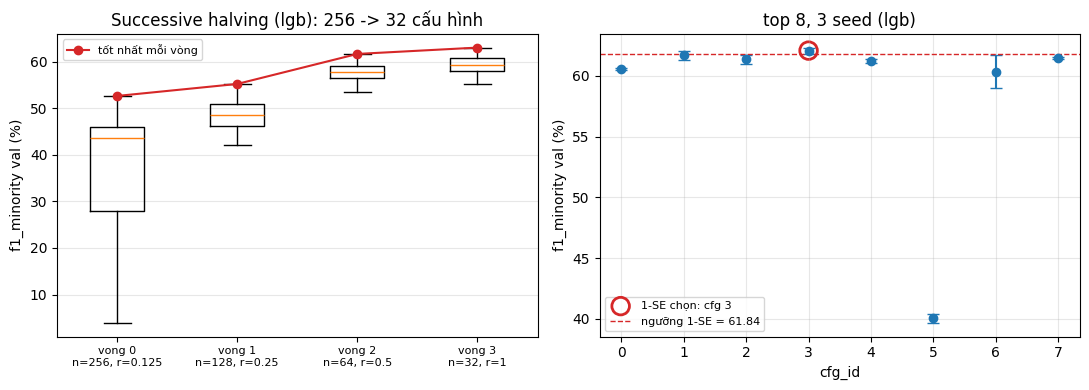

In [1]:
# H2-lgb. lgb: quy trình chọn tham số
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

hal = pd.read_csv("tune_lgb_halving.csv")
con = pd.read_csv("tune_lgb_confirm.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# --- trai: phan bo f1 qua tung vong halving
rounds = sorted(hal["round"].unique())
data = [hal.loc[hal["round"] == r, "f1_val"].values * 100 for r in rounds]
ax1.boxplot(data, showfliers=False)
ax1.set_xticks(range(1, len(rounds) + 1))
ax1.set_xticklabels([f"vong {r}\nn={len(data[i])}, r={hal.loc[hal['round']==r,'r'].iloc[0]:g}"
                     for i, r in enumerate(rounds)], fontsize=8)
ax1.plot(range(1, len(rounds) + 1), [d.max() for d in data],
         marker="o", color="tab:red", label="tốt nhất mỗi vòng")
ax1.set_ylabel("f1_minority val (%)")
ax1.set_title("Successive halving (lgb): 256 -> 32 cấu hình")
ax1.legend(fontsize=8); ax1.grid(alpha=.3, axis="y")

# --- phai: xac nhan top-8 bang 3 seed, kem nguong 1-SE
g = con.groupby("cfg_id").f1_val
mu, se = g.mean() * 100, g.std(ddof=1) / np.sqrt(g.count()) * 100
b = mu.idxmax(); cutoff = mu[b] - se[b]
chosen = next(i for i in sorted(mu.index) if mu[i] >= cutoff)

ax2.errorbar(mu.index, mu.values, yerr=se.values, fmt="o", capsize=4, color="tab:blue")
ax2.scatter([chosen], [mu[chosen]], s=160, facecolors="none",
            edgecolors="tab:red", linewidths=2, label=f"1-SE chọn: cfg {chosen}")
ax2.axhline(cutoff, ls="--", color="tab:red", lw=1, label=f"ngưỡng 1-SE = {cutoff:.2f}")
ax2.set_xlabel("cfg_id")
ax2.set_ylabel("f1_minority val (%)")
ax2.set_title("top 8, 3 seed (lgb)")
ax2.legend(fontsize=8); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()


In [6]:
from sklearn.tree import DecisionTreeClassifier

DT_SEEDS = [0, 1, 2]
DT_MSL   = [625, 125, 25, 5, 1]        # DON GIAN -> PHUC TAP, buoc x5, phu 3 bac
DT_DEPTH = [8, 12, 16, 24, None]       # None = khong chan, de msl quyet do phuc tap

DT_GRID = [{"min_samples_leaf": m, "max_depth": d, "class_weight": "balanced"}
           for m in DT_MSL for d in DT_DEPTH]

rows = []
for cfg_id, cfg in enumerate(DT_GRID):
    for seed in DT_SEEDS:
        m = DecisionTreeClassifier(**cfg, random_state=seed)
        t0 = time.time(); m.fit(X_tr, y_tr); el = time.time() - t0
        s = m.predict_proba(X_va)[:, 1]
        e = evaluate(y_va, s, find_best_threshold(y_va, s))
        rows.append({"cfg_id": cfg_id, "seed": seed,
                     "min_samples_leaf": cfg["min_samples_leaf"],
                     "max_depth": -1 if cfg["max_depth"] is None else cfg["max_depth"],
                     "f1_val": e["f1_minority"], "pr_auc": e["pr_auc"],
                     "recall": e["recall"], "threshold": e["threshold"],
                     "depth_that": int(m.get_depth()),      # do sau THUC TE -> max_depth co rang buoc?
                     "n_leaf": int(m.get_n_leaves()),       # so la -> do min cua predict_proba
                     "fit_s": round(el, 1), "params": json.dumps(cfg)})
        r = rows[-1]
        print(f"  cfg {cfg_id:<2} msl={r['min_samples_leaf']:<4} "
              f"depth={str(cfg['max_depth']):<5} seed={seed}  "
              f"f1={r['f1_val']*100:5.2f}  pr_auc={r['pr_auc']*100:5.2f}  "
              f"rec={r['recall']:.4f}  d*={r['depth_that']:<3} la={r['n_leaf']:<7} ({r['fit_s']}s)")
        pd.DataFrame(rows).to_csv("tune_dt.csv", index=False)

tune_dt = pd.DataFrame(rows)
print(f"\n  da ghi tune_dt.csv ({len(tune_dt)} dong, tong {tune_dt.fit_s.sum()/60:.1f} phut)")

  cfg 0  msl=625  depth=8     seed=0  f1=52.79  pr_auc=35.61  rec=0.4159  d*=8   la=54      (21.7s)
  cfg 0  msl=625  depth=8     seed=1  f1=52.79  pr_auc=35.60  rec=0.4159  d*=8   la=53      (21.9s)
  cfg 0  msl=625  depth=8     seed=2  f1=52.79  pr_auc=35.62  rec=0.4159  d*=8   la=53      (22.0s)
  cfg 1  msl=625  depth=12    seed=0  f1=52.79  pr_auc=37.55  rec=0.4159  d*=12  la=90      (22.7s)
  cfg 1  msl=625  depth=12    seed=1  f1=52.79  pr_auc=37.55  rec=0.4159  d*=12  la=93      (22.8s)
  cfg 1  msl=625  depth=12    seed=2  f1=52.79  pr_auc=37.55  rec=0.4159  d*=12  la=93      (22.9s)
  cfg 2  msl=625  depth=16    seed=0  f1=52.79  pr_auc=37.80  rec=0.4159  d*=16  la=107     (23.1s)
  cfg 2  msl=625  depth=16    seed=1  f1=52.79  pr_auc=37.81  rec=0.4159  d*=16  la=107     (23.2s)
  cfg 2  msl=625  depth=16    seed=2  f1=52.79  pr_auc=37.82  rec=0.4159  d*=16  la=110     (23.2s)
  cfg 3  msl=625  depth=24    seed=0  f1=52.79  pr_auc=37.81  rec=0.4159  d*=24  la=120     (23.4s)


--- dt: quy tac 1-SE tren tune_dt.csv ---
  argmax      : cfg 13  mean=0.584257  se=0.000000
  nguong 1-SE : 0.584257
  1-SE chon   : cfg 13  msl=25  depth=24  f1=58.43 +- 0.00

  dieu kien (1) - khong cham mep:
    min_samples_leaf  = 25    vi tri 3/5   -> noi vi - OK
    max_depth         = 24    vi tri 4/5   -> noi vi - OK
  => dieu kien (1): DAT

  do sau THUC TE cua cay thang = 24  (max_depth dat = 24)
  so la = 400  -> predict_proba co 400 muc roi rac; cang it la thi PR curve cang bac thang
  recall = 0.4630  threshold = 0.997413

        msl  depth  f1_mean    se  d_that  n_leaf dat_1SE
cfg_id                                                   
0       625      8    52.79  0.00     8.0    53.0       .
1       625     12    52.79  0.00    12.0    92.0       .
2       625     16    52.79  0.00    16.0   108.0       .
3       625     24    52.79  0.00    24.0   122.0       .
4       625     -1    52.79  0.00    24.0   122.0       .
5       125      8    53.44  0.00     8.0    68.0  

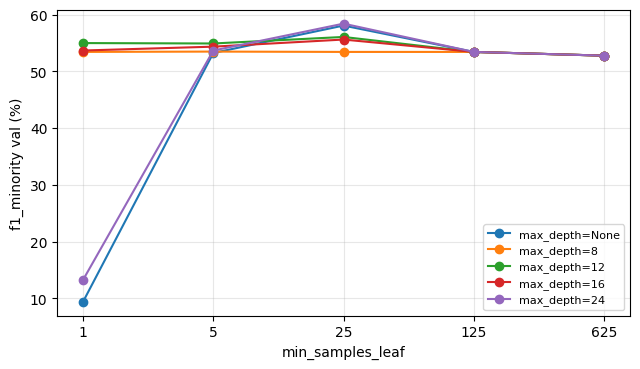


  params dt duoc chon:
{
    "min_samples_leaf": 25,
    "max_depth": 24,
    "class_weight": "balanced"
}


In [7]:
# L2. dt: quy tac 1-SE + KIEM TRA DIEU KIEN "da tune toi nguong"
d = pd.read_csv("tune_dt.csv")
g = d.groupby("cfg_id").f1_val
mu = g.mean(); se = g.std(ddof=1) / np.sqrt(g.count())

b = mu.idxmax()
cutoff = mu[b] - se[b]
chosen = next(i for i in sorted(mu.index) if mu[i] >= cutoff)
w = d[d.cfg_id == chosen].iloc[0]

print("--- dt: quy tac 1-SE tren tune_dt.csv ---")
print(f"  argmax      : cfg {b}  mean={mu[b]:.6f}  se={se[b]:.6f}")
print(f"  nguong 1-SE : {cutoff:.6f}")
print(f"  1-SE chon   : cfg {chosen}  msl={int(w.min_samples_leaf)}  "
      f"depth={'None' if w.max_depth == -1 else int(w.max_depth)}  "
      f"f1={mu[chosen]*100:.2f} +- {se[chosen]*100:.2f}\n")

# --- DIEU KIEN (1): cfg thang co cham mep truc nao khong? ---
print("  dieu kien (1) - khong cham mep:")
ok = True
for ax, vals in [("min_samples_leaf", DT_MSL), ("max_depth", DT_DEPTH)]:
    v = w[ax]
    v = None if (ax == "max_depth" and v == -1) else int(v)
    i = vals.index(v)
    edge = i in (0, len(vals) - 1)
    ok &= not edge
    print(f"    {ax:<17} = {str(v):<5} vi tri {i+1}/{len(vals)}   "
          f"-> {'MEP: phai noi truc nay roi chay lai' if edge else 'noi vi - OK'}")
print(f"  => dieu kien (1): {'DAT' if ok else 'CHUA DAT'}\n")

# --- max_depth co thuc su rang buoc khong? ---
print(f"  do sau THUC TE cua cay thang = {int(w.depth_that)}  "
      f"(max_depth dat = {'None' if w.max_depth == -1 else int(w.max_depth)})")
print(f"  so la = {int(w.n_leaf)}  -> predict_proba co {int(w.n_leaf)} muc roi rac; "
      f"cang it la thi PR curve cang bac thang")
print(f"  recall = {w.recall:.4f}  threshold = {w.threshold:.6f}\n")

# --- bang day du + heatmap ---
tab = pd.DataFrame({"msl": g.first().index.map(lambda i: d[d.cfg_id == i].min_samples_leaf.iloc[0]),
                    "depth": g.first().index.map(lambda i: d[d.cfg_id == i].max_depth.iloc[0]),
                    "f1_mean": (mu * 100).round(2), "se": (se * 100).round(2),
                    "d_that": d.groupby("cfg_id").depth_that.mean().round(0),
                    "n_leaf": d.groupby("cfg_id").n_leaf.mean().round(0),
                    "dat_1SE": [("X" if mu[i] >= cutoff else ".") for i in sorted(mu.index)]})
print(tab.to_string())

piv = (d.pivot_table(index="min_samples_leaf", columns="max_depth",
                     values="f1_val", aggfunc="mean") * 100)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for dep in piv.columns:
    ax.plot(piv.index.astype(str), piv[dep], marker="o",
            label=f"max_depth={'None' if dep == -1 else dep}")
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("f1_minority val (%)")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

p = json.loads(d[d.cfg_id == chosen].params.iloc[0])
print("\n  params dt duoc chon:")
print(json.dumps(p, indent=4))

b=2
SE = 0.00  f1_mean = 40.99
idx best config = 2 (f1_mean=40.99)   chạm biên grid
  best config -> {'C': 1.0, 'class_weight': None, 'max_iter': 1000}

b=1
SE = 0.07  f1_mean = 55.12
idx best config = 1 (f1_mean=55.19)
  best config -> {'max_depth': 16, 'class_weight': 'balanced'}

b=5
SE = 0.38  f1_mean = 58.87
idx best config = 5 (f1_mean=59.26)   chạm biên grid
  best config -> {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'n_jobs': -1}

b=7
SE = 0.30  f1_mean = 62.99
idx best config = 4 (f1_mean=63.13)
  best config -> {'max_depth': 8, 'learning_rate': 0.05, 'scale_pos_weight': 5, 'reg_lambda': 1.0, 'n_estimators': 1000, 'early_stopping_rounds': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'n_jobs': -1}

b=0
SE = 1.29  f1_mean = 54.64
idx best config = 0 (f1_mean=55.93)   chạm biên grid
  best config -> {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001, 'batch_size': 512, 'max_iter': 30, 'early_stopping': False}

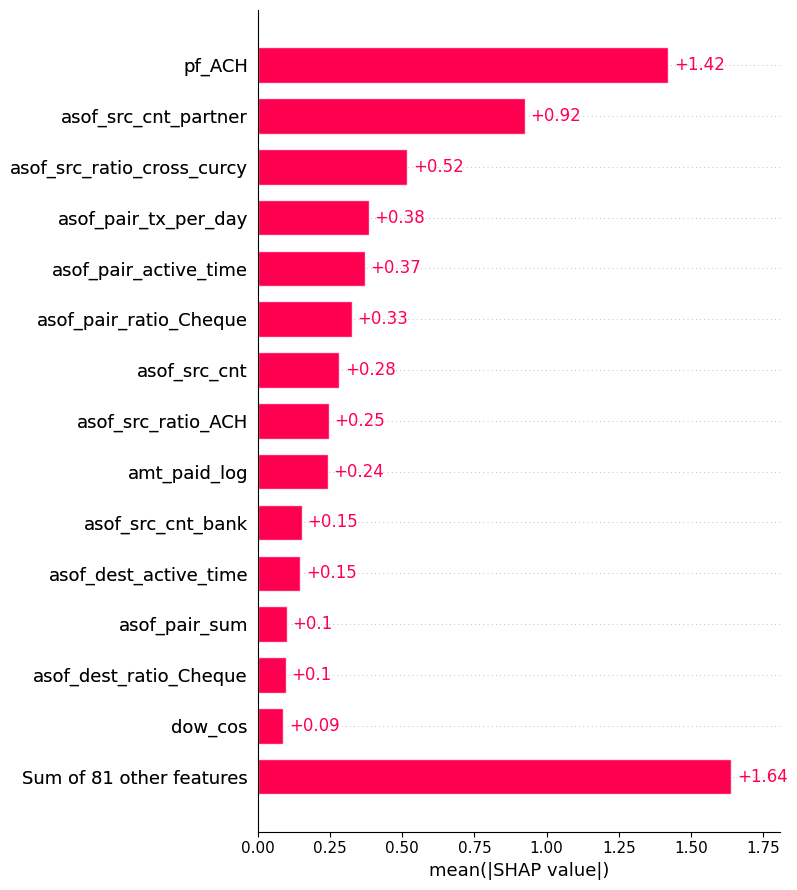

In [10]:
#4. kiểm tra kết quả results
import json, importlib
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import shap
import train_classical as tc
importlib.reload(tc)

SHOW = ("C", "max_depth", "min_samples_leaf", "n_estimators",
        "scale_pos_weight", "reg_lambda", "hidden_layer_sizes")

df = pd.read_csv("results.csv")
df = df[(df.stage == "tune") & (df.split == "val")]
df = df.drop_duplicates(subset=["model", "params", "seed"], keep="last")

all_tables = []
for name, grid in tc.GRIDS.items():
    rows = []
    for cfg in grid:
        f = df[(df.model == name) & (df.params == json.dumps(cfg))].f1_minority
        rows.append({"n_seed": len(f),
                     "f1_mean": f.mean() * 100 if len(f) else np.nan,
                     "f1_sd": f.std(ddof=1) * 100 if len(f) > 1 else np.nan,
                     **{k: v for k, v in cfg.items() if k in SHOW}})
    r = pd.DataFrame(rows)
    r.insert(0, "model", name)
    all_tables.append(r)

    if (r.n_seed < 2).any():
        continue
    se = r.f1_sd / np.sqrt(r.n_seed)
    b = int(r.f1_mean.idxmax())
    cutoff = r.f1_mean[b] - se[b]
    pick = int(next(i for i, m in enumerate(r.f1_mean) if m >= cutoff))
    print(f"b={b}")
    print(f"SE = {se[b]:.2f}  f1_mean = {cutoff:.2f}")
    print(f"idx best config = {pick} (f1_mean={r.f1_mean[pick]:.2f})"
          f"{'   chạm biên grid' if b in (0, len(grid) - 1) else ''}")
    print(f"  best config -> {tc.pick_best(name)}\n")
pd.concat(all_tables, ignore_index=True).to_csv("config_1.csv", index=False)

def per_axis(name, axes):
    d = df[df.model == name].reset_index(drop=True)
    p = d.params.apply(json.loads).apply(pd.Series)
    d = pd.concat([d[["f1_minority"]], p[axes]], axis=1)
    print(f"--- {name}: ")
    for a in axes:
        other = [x for x in axes if x != a]
        t = d.pivot_table(index=other, columns=a, values="f1_minority", aggfunc="mean")
        print((t * 100).round(2).to_string(), "\n")
# per_axis("rf",  ["n_estimators", "min_samples_leaf"])
# per_axis("xgb", ["reg_lambda", "scale_pos_weight"])
feat_names = [c for c in pq.ParquetFile("dataset_high/txn_matrix_val.parquet")
              .schema_arrow.names if c != "Is Laundering"]
xgb_model = tc.XGBClassifier()
xgb_model.load_model("models/xgboost_seed0.json")
rng = np.random.RandomState(0)
idx = rng.choice(len(X_va), size=5000, replace=False)
X_shap = X_va[idx]
explainer=shap.TreeExplainer(xgb_model)
exp=explainer(X_shap)
exp.feature_names=feat_names
y_shap=y_va[idx]
fraud=np.where(y_shap)
i=fraud[0]
shap.plots.bar(exp[i],max_display=15,show=False)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
metrics = ["f1_minority", "precision", "recall", "pr_auc",
           "recall@fpr1%", "precision@1000"]

agg = df.groupby(["model", "split"])[metrics].agg(["mean", "std"]).round(4)
agg

f1_minority         precision          recall          pr_auc  \
                   mean     std      mean     std    mean     std    mean   
model split                                                                 
dt    test       0.6215  0.0192    0.7237  0.0511  0.5457  0.0067  0.4359   
      val        0.5561  0.0168    0.7163  0.0496  0.4558  0.0163  0.3707   
lr    test       0.4291  0.0000    0.3730  0.0000  0.5050  0.0000  0.4622   
      val        0.3301  0.0000    0.3038  0.0000  0.3614  0.0000  0.2913   
mlp   test       0.7033  0.0115    0.7995  0.0394  0.6289  0.0195  0.7044   
      val        0.6313  0.0077    0.8263  0.0280  0.5111  0.0074  0.5956   
rf    test       0.6923  0.0016    0.8887  0.0077  0.5671  0.0049  0.6855   
      val        0.5308  0.1522    0.6794  0.2720  0.4495  0.0756  0.4942   
xgb   test       0.7386  0.0000    0.9203  0.0000  0.6168  0.0000  0.7298   
      val        0.6500  0.0213    0.8829  0.0467  0.5153  0.0229  0.6089   

                    recall@fpr1%         precision@1000          
                std         mean     std           mean     std  
model split                                                      
dt    test   0.0322       0.7761  0.0050         0.6480  0.0925  
      val    0.0300       0.7535  0.0269         0.5132  0.0217  
lr    test   0.0000       0.7764  0.0000         0.6190  0.0000  
      val    0.0000       0.7468  0.0000         0.3320  0.0000  
mlp   test   0.0129       0.8773  0.0079         0.9176  0.0235  
      val    0.0107       0.8257  0.0046         0.6006  0.0102  
rf    test   0.0010       0.8343  0.0041         0.9252  0.0016  
      val    0.1485       0.7978  0.0144         0.5129  0.1371  
xgb   test   0.0000       0.8804  0.0000         0.9500  0.0000  
      val    0.0311       0.8200  0.0146         0.6125  0.0256